# Model Traininig 
1. data cleaning 
2. preprocessing 
3. model training 
4. validation 

### Imports

In [177]:
import pandas as pd 
import numpy as np 

# time 
import time 

# visualization 
import seaborn as sns 
import matplotlib.pyplot as plt 

# preprocessing 
from sklearn.impute import SimpleImputer   # missing values 
from sklearn.preprocessing import LabelEncoder , OrdinalEncoder , OneHotEncoder 

# scalling 
from sklearn.preprocessing import StandardScaler  

# spliting data 
from sklearn.model_selection import train_test_split 

# models 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier 

# pipeilne 
from sklearn.pipeline import Pipeline

# column transformer 
from sklearn.compose import ColumnTransformer 

# parameter tunning 
import  optuna 

# evaluation 
from sklearn.metrics import roc_auc_score , ConfusionMatrixDisplay, classification_report , confusion_matrix, precision_score , recall_score

### Load data 

In [178]:
df = pd.read_csv('..\Data\customer_churn_dataset-training-master.csv')
test_data = pd.read_csv('..\Data\customer_churn_dataset-testing-master.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [179]:
df.head() 


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [181]:
df.describe() 

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


### Data Cleaning 

In [182]:
# Droping customer Id 
df.drop(columns=['CustomerID'] , inplace= True )
test_data.drop(columns=['CustomerID'] , inplace=True )

In [183]:
df.head() 

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [184]:
df.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='object')

In [185]:
numarical_columns = [  'Age',  'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay',  'Total Spend',
       'Last Interaction']

categorical_columns = ['Gender','Subscription Type','Contract Length' ]

<Axes: >

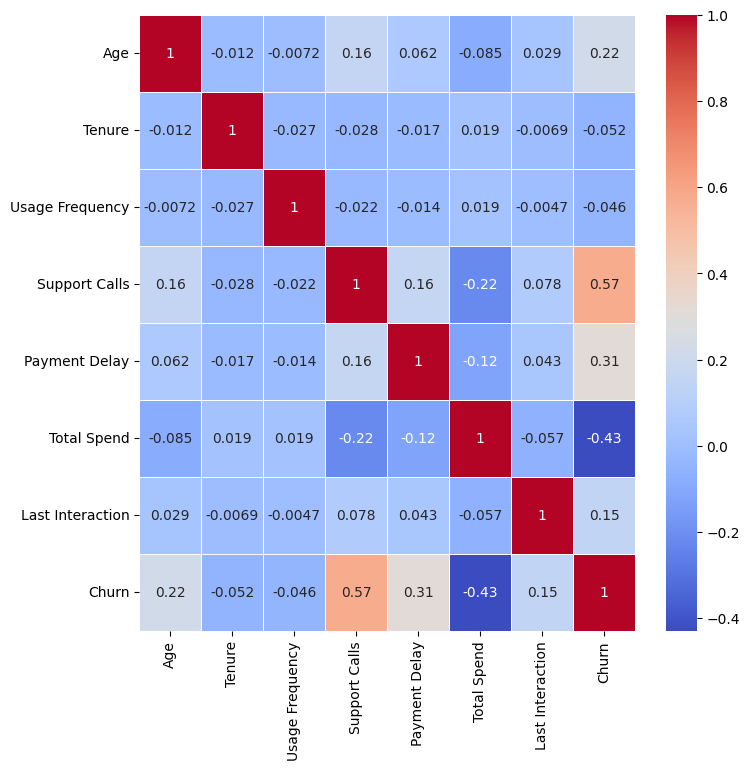

In [186]:
## ploting relationship between features 
corr = df.corr(numeric_only=True )
plt.figure(figsize=(8,8))
sns.heatmap(data= corr  , annot=True , cmap='coolwarm' ,linewidths=0.5 )

In [187]:
corr = df.corr(numeric_only=True)
corr['Churn'].sort_values(ascending=False)

Churn               1.000000
Support Calls       0.574267
Payment Delay       0.312129
Age                 0.218394
Last Interaction    0.149616
Usage Frequency    -0.046101
Tenure             -0.051919
Total Spend        -0.429355
Name: Churn, dtype: float64

Observation :- 
   1. all features are contributing in churn and have multicoliniarity between featurs  
   2. these feature are with less muliticoliniarly related to other features 
   3. also less contributting to the dependent features 

removing age and Last Interaction becouse there are weak and useless columns for churn  

In [188]:
df.info( )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                440832 non-null  float64
 1   Gender             440832 non-null  object 
 2   Tenure             440832 non-null  float64
 3   Usage Frequency    440832 non-null  float64
 4   Support Calls      440832 non-null  float64
 5   Payment Delay      440832 non-null  float64
 6   Subscription Type  440832 non-null  object 
 7   Contract Length    440832 non-null  object 
 8   Total Spend        440832 non-null  float64
 9   Last Interaction   440832 non-null  float64
 10  Churn              440832 non-null  float64
dtypes: float64(8), object(3)
memory usage: 37.0+ MB


In [189]:
test_data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                64374 non-null  int64 
 1   Gender             64374 non-null  object
 2   Tenure             64374 non-null  int64 
 3   Usage Frequency    64374 non-null  int64 
 4   Support Calls      64374 non-null  int64 
 5   Payment Delay      64374 non-null  int64 
 6   Subscription Type  64374 non-null  object
 7   Contract Length    64374 non-null  object
 8   Total Spend        64374 non-null  int64 
 9   Last Interaction   64374 non-null  int64 
 10  Churn              64374 non-null  int64 
dtypes: int64(8), object(3)
memory usage: 5.4+ MB


In [190]:
df['Churn'].value_counts() 

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64

In [191]:
test_data['Churn'].value_counts() 

Churn
0    33881
1    30493
Name: count, dtype: int64

### Balance of data 

### split data 

In [192]:
df.head() 

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [193]:
# training and validation 
X = df.iloc[ :, :-1]
y = df.iloc[: , -1 ]

# testing data 
X_test = test_data.iloc[:,:-1] 
y_test = test_data.iloc[: , -1 ]

X_test.shape ,y_test.shape 

((64374, 10), (64374,))

In [194]:
# train and val 
X_train , X_val , y_train  , y_val = train_test_split(X,y , random_state=42 , test_size=0.2 )
y_train.shape

X_train.shape , X_val.shape

((352666, 10), (88167, 10))

In [195]:
y_train = y_train.fillna(0)

y_val.isnull().sum() 

np.int64(0)

### Preprocessing 
building pipeline for the feature to convert them into numaric values  
columns :-  Gender , Subscription Type , Contract Lenght 

#### Pipelilnes 

In [196]:
## Gender 

gender_pipe = Pipeline( steps =[ 
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('OHT' , OneHotEncoder(handle_unknown='ignore')) ,
])
    
    
gender_pipe

,steps,"[('imputer', ...), ('OHT', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


In [197]:
df['Subscription Type'].value_counts( )

Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64

In [198]:
# Subscription Type :- ordinal data so use ordinal encoding 

subscription_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent' ) ), 
    ('sub_type_order', OrdinalEncoder(categories=[['Basic', 'Standard', 'Premium']])) , 
])

In [199]:
df.head() 

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [200]:
df['Contract Length'].value_counts()

Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64

In [201]:
# 	Contract Length

contrat_len_pipe = Pipeline( steps = [
     ('imputer', SimpleImputer(strategy='most_frequent')),
    ( 'contrac_encode' , OrdinalEncoder(categories=[['Monthly', 'Quarterly', 'Annual']]))
])


In [202]:
# Scaling pipelilne 

scaler_pipe  = Pipeline(steps= [ 
     ('imputer', SimpleImputer(strategy='mean')) , 
    ( 'Scaler' , StandardScaler() )
])

#### column Transformer 

In [203]:
X_train.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction'],
      dtype='object')

In [204]:
num_columns = ['Age',  'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay',  'Total Spend',
       'Last Interaction']
preprocessor = ColumnTransformer( transformers=  [ 
    ('gender_pipe' , gender_pipe , ['Gender']) , 
    ('subscription_pipe' , subscription_pipe , ['Subscription Type'] ) , 
    ('contrat_len_pipe' , contrat_len_pipe,  ['Contract Length']  ) , 
    ('scaler' , scaler_pipe , num_columns)
] , remainder ="passthrough" 
)
preprocessor

,transformers,"[('gender_pipe', ...), ('subscription_pipe', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


#### Model Chossing with best parameters 

Note :- 
1. In churn prediction we need to Reduce the values of the False negative which actually Cause the comapny 
2. If churn is true and predicting it is not a churn 
3. Minimize the Recall 

#### Random Forest 

In [205]:
def objective(trial):

    r_params = {
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'ccp_alpha': trial.suggest_float('ccp_alpha', 0.0, 0.05),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
        'max_depth': trial.suggest_int('max_depth', 10, 40, step=5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50)
    }

    random_forest_pipe =  Pipeline(steps = [
            ('Preprocessor' , preprocessor) , 
            ('RandomForestClassifier' , RandomForestClassifier(**r_params, n_jobs=-1, random_state=42))
            ])

    random_forest_pipe.fit(X_train, y_train)
    y_pred = random_forest_pipe.predict_proba(X_val)[: , 1]

    return roc_auc_score(y_val, y_pred)

In [206]:

study = optuna.create_study(direction='maximize')

[I 2026-04-18 16:23:06,349] A new study created in memory with name: no-name-68cf8f79-0d4a-42af-a7a8-8c6def1a12d4


In [207]:
# optimize 
s = time.time() 
study.optimize(objective , n_trials= 10 )
print(f"Training time : {time.time() - s}")

[I 2026-04-18 16:23:13,707] Trial 0 finished with value: 0.9943629606094136 and parameters: {'bootstrap': True, 'ccp_alpha': 0.020058954746361497, 'criterion': 'gini', 'max_depth': 35, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 100}. Best is trial 0 with value: 0.9943629606094136.
[I 2026-04-18 16:23:28,471] Trial 1 finished with value: 0.9937407062673519 and parameters: {'bootstrap': False, 'ccp_alpha': 0.033343964049762656, 'criterion': 'log_loss', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 6, 'n_estimators': 200}. Best is trial 0 with value: 0.9943629606094136.
[I 2026-04-18 16:23:54,295] Trial 2 finished with value: 0.999038375744758 and parameters: {'bootstrap': True, 'ccp_alpha': 0.0019177725732666185, 'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 400}. Best is trial 2 with value: 0.999038375744758.
[I 2026-04-18 16:

Training time : 183.8247685432434


In [208]:
r_params = study.best_params
r_params

{'bootstrap': True,
 'ccp_alpha': 0.0005790315332087625,
 'criterion': 'gini',
 'max_depth': 15,
 'max_features': 'sqrt',
 'min_samples_leaf': 8,
 'min_samples_split': 10,
 'n_estimators': 150}

In [209]:
study.best_value

0.9998556422670939

##### Training and testing model on best parameters 

In [270]:
from imblearn.combine import SMOTEENN

random_forest = Pipeline(steps = [ 
    ('preprocessor' , preprocessor ) , 
    ( 'Random_Forest' , RandomForestClassifier(**r_params , n_jobs=-1 , random_state=42)) ,
    ]  , )

random_forest.fit(X_train,y_train) 
y_pred = random_forest.predict_proba(X_test)[:, 1]

print(f'roc_auc_score: { roc_auc_score(y_test,y_pred)  }')


roc_auc_score: 0.6673136723776582


In [211]:
threshold  = 0.5
# threshold values 
y_pred= (y_pred > threshold ).astype(int)

print(f"precision_score :{ precision_score(y_test,y_pred )}")
print(f"Recall_score : {recall_score(y_test,y_pred )}")
cm = confusion_matrix(y_test, y_pred)


precision_score :0.4921263661643924
Recall_score : 0.99822910176106


Threshold: 0.3
Precision: 0.9949613100593846
Recall: 0.9947425235886774
------------------------------
Threshold: 0.4
Precision: 0.9949357930909749
Recall: 0.9897049416280186
------------------------------
Threshold: 0.5
Precision: 0.9949181253529079
Recall: 0.986246601631217
------------------------------
Threshold: 0.6
Precision: 0.9960678598212295
Recall: 0.9823884535422996
------------------------------
Threshold: 0.7
Precision: 0.9999796379629818
Recall: 0.9817287701903087
------------------------------


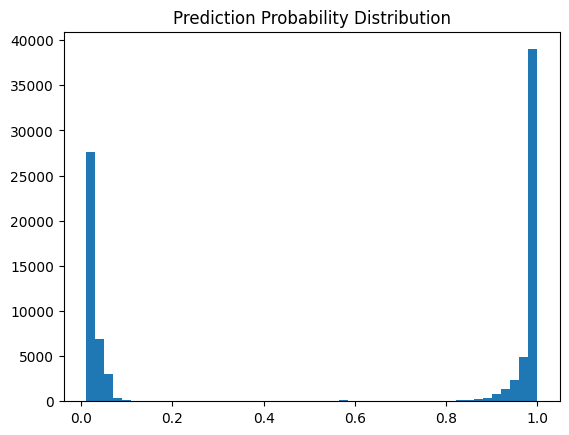

In [212]:
### precisoin recal values with different threshold 
y_prob = random_forest.predict_proba(X_val)[:, 1]

for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_temp = (y_prob > t).astype(int)   
    
    print(f"Threshold: {t}")
    print(f"Precision: {precision_score(y_val, y_temp)}")
    print(f"Recall: {recall_score(y_val, y_temp)}")
    print("-"*30)

plt.hist(y_prob, bins=50)
plt.title("Prediction Probability Distribution")
plt.show()

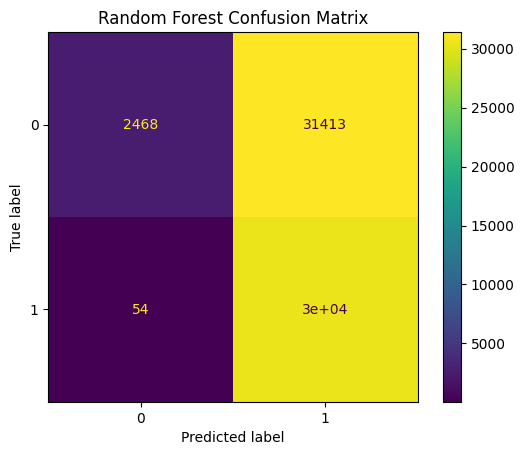

In [213]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

Observation:- Results are quite confusion becouse the recall values are reduced and precision values also increase 
model not predictiong true negative values here 

#### Xgboost Model 

In [214]:
print(XGBClassifier().get_params() )


{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [215]:
def objective(trial) : 
    xgb_params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",

        # Core parameters
        "n_estimators": trial.suggest_int("n_estimators", 100, 500 , step = 50 ),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),

        # Regularization
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 1.0),

        # Tree-specific
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),

        # Sampling
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),

        # Imbalance handling (important for churn)
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1, 10),

        # Performance
        "random_state": 42,
        "n_jobs": -1
    }
 
    xgb_pipe = Pipeline( steps= [ 
        ( 'preprocessor' , preprocessor ) , 
        ('xgb' , XGBClassifier(**xgb_params ) )
        ] ) 
    xgb_pipe.fit(X_train , y_train) 
    y_pred = xgb_pipe.predict_proba(X_val)[:, 1]

    Accuracy = roc_auc_score(y_val, y_pred ) 

    return Accuracy 

In [216]:
study = optuna.create_study(direction= 'maximize') 

[I 2026-04-18 16:26:20,875] A new study created in memory with name: no-name-8259ba33-9ca1-4434-8b41-21dd3aafad1f


In [217]:
s = time.time() 
study.optimize(objective , n_trials= 10 )
print(f"Training time : {time.time() - s}")

[I 2026-04-18 16:26:22,628] Trial 0 finished with value: 0.9996461001867781 and parameters: {'n_estimators': 150, 'max_depth': 7, 'learning_rate': 0.01711561878487492, 'reg_alpha': 0.33261112997887143, 'reg_lambda': 0.3042832149935568, 'min_child_weight': 8, 'gamma': 0.3234642135500604, 'subsample': 0.6647555000960239, 'colsample_bytree': 0.8900090084629404, 'scale_pos_weight': 7.943793343336481}. Best is trial 0 with value: 0.9996461001867781.
[I 2026-04-18 16:26:26,129] Trial 1 finished with value: 0.9999996902621943 and parameters: {'n_estimators': 350, 'max_depth': 10, 'learning_rate': 0.07052599389834095, 'reg_alpha': 0.9375804449126676, 'reg_lambda': 0.39672452312191064, 'min_child_weight': 10, 'gamma': 0.7614396432676451, 'subsample': 0.6548893362463681, 'colsample_bytree': 0.8531519182020508, 'scale_pos_weight': 6.414739591630894}. Best is trial 1 with value: 0.9999996902621943.
[I 2026-04-18 16:26:30,315] Trial 2 finished with value: 0.999993523806997 and parameters: {'n_estim

Training time : 29.591173887252808


In [218]:
study.best_value

0.9999996902621943

In [219]:
xgb_params = study.best_params

In [220]:
## Train 
xgb_pipe = Pipeline( steps= [ 
        ( 'preprocessor' , preprocessor ) , 
        ('xgb' , XGBClassifier(**xgb_params ) )
        ] ) 

xgb_pipe.fit(X_train,y_train) 
y_pred = xgb_pipe.predict_proba(X_test)[:, 1]

print(f'Accuracy : {roc_auc_score(y_test,y_pred)} ')

y_pred= (y_pred > threshold ).astype(int)
print(f'precission : {precision_score(y_test,y_pred)}')
print(f'Recall: { recall_score(y_test, y_pred )}' ) 

cm = confusion_matrix(y_test , y_pred )

Accuracy : 0.6758051852538571 
precission : 0.488169664326248
Recall: 0.998688223526711


Threshold: 0.3
Precision: 0.9997801231310466
Recall: 0.9998600671677594
------------------------------
Threshold: 0.4
Precision: 0.9999200335858939
Recall: 0.9998600671677594
------------------------------
Threshold: 0.5
Precision: 0.9999200335858939
Recall: 0.9998600671677594
------------------------------
Threshold: 0.6
Precision: 0.9999600151942262
Recall: 0.9998600671677594
------------------------------
Threshold: 0.7
Precision: 1.0
Recall: 0.9998400767631537
------------------------------


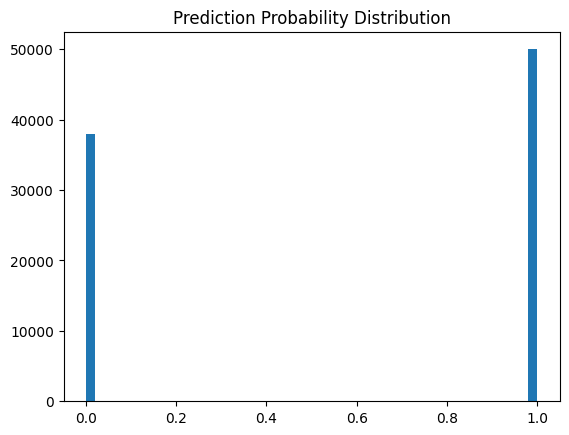

In [221]:
# precisoin recall llwith different threshold 
y_prob = xgb_pipe.predict_proba(X_val)[:, 1]

for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_temp = (y_prob > t).astype(int)   # ✅ use new variable
    
    print(f"Threshold: {t}")
    print(f"Precision: {precision_score(y_val, y_temp)}")
    print(f"Recall: {recall_score(y_val, y_temp)}")
    print("-"*30)


plt.hist(y_prob, bins=50)
plt.title("Prediction Probability Distribution")
plt.show()

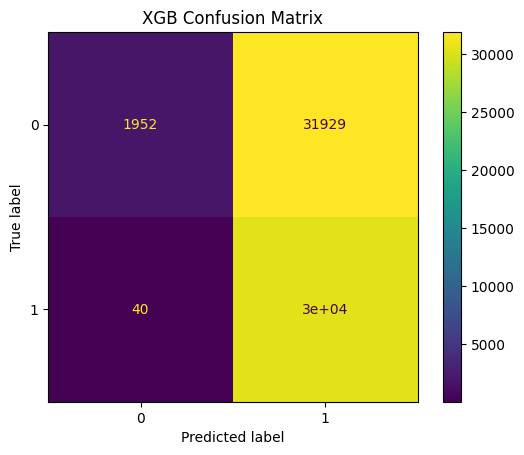

In [222]:
disp = ConfusionMatrixDisplay( confusion_matrix= cm ) 

disp.plot()
plt.title("XGB Confusion Matrix")
plt.show() 

Observations :- 
1. from abouve graph it show's that the model reduced the recall values to much 
2. XGBoost classifier is giving good values for churn prediction 

#### Light GBM 

In [223]:
def objective(trial) : 
    LGBM_params= { 
        "objective": "binary",
        "metric": "auc",

        # Core parameters
        "n_estimators": trial.suggest_int("n_estimators", 100, 500 , step = 50 ),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),

        # Tree complexity
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 12),

        # Regularization
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 1.0),

        # Sampling
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "force_row_wise" : True , 
        "force_row_wise" : True ,
        # Imbalance handling
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1, 10),
        # Speed
        "random_state": 42,
        "n_jobs": -1
    }

    LGBM_pipe = Pipeline(steps= [ 
        ( 'preprocessor' , preprocessor ), 
        ( 'Light_GBM'  , LGBMClassifier(**LGBM_params))
    ])

    LGBM_pipe.fit(X_train,y_train )
    y_pred = LGBM_pipe.predict_proba(X_val)[:, 1] 

    return  roc_auc_score(y_val,y_pred) 

In [224]:
study = optuna.create_study(direction='maximize') 

[I 2026-04-18 16:26:54,408] A new study created in memory with name: no-name-b16e1349-c0ca-4519-85fa-4d88519cfdbe


In [225]:
LGBMClassifier().get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': -1,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'num_leaves': 31,
 'objective': None,
 'random_state': None,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0}

In [226]:
s = time.time() 
study.optimize(objective , n_trials= 10 )
print(f"Training time : {time.time() - s}")

[LightGBM] [Info] Number of positive: 199975, number of negative: 152691
[LightGBM] [Info] Total Bins 481
[LightGBM] [Info] Number of data points in the train set: 352666, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567038 -> initscore=0.269776
[LightGBM] [Info] Start training from score 0.269776
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-18 16:26:57,470] Trial 0 finished with value: 0.9999826504901537 and parameters: {'n_estimators': 450, 'learning_rate': 0.013403636093982176, 'num_leaves': 100, 'max_depth': 8, 'min_child_samples': 26, 'reg_alpha': 0.3427002675373798, 'reg_lambda': 0.859634982742388, 'subsample': 0.6470070669651649, 'colsample_bytree': 0.9894366597399427, 'scale_pos_weight': 8.25081727081707}. Best is trial 0 with value: 0.9999826504901537.


[LightGBM] [Info] Number of positive: 199975, number of negative: 152691
[LightGBM] [Info] Total Bins 481
[LightGBM] [Info] Number of data points in the train set: 352666, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567038 -> initscore=0.269776
[LightGBM] [Info] Start training from score 0.269776
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-18 16:27:00,928] Trial 1 finished with value: 0.9999929939509538 and parameters: {'n_estimators': 400, 'learning_rate': 0.010855727870511795, 'num_leaves': 87, 'max_depth': 10, 'min_child_samples': 11, 'reg_alpha': 0.25445837094808665, 'reg_lambda': 0.10605521268673712, 'subsample': 0.8469810111740528, 'colsample_bytree': 0.8021032831993629, 'scale_pos_weight': 6.13675018754116}. Best is trial 1 with value: 0.9999929939509538.


[LightGBM] [Info] Number of positive: 199975, number of negative: 152691
[LightGBM] [Info] Total Bins 481
[LightGBM] [Info] Number of data points in the train set: 352666, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567038 -> initscore=0.269776
[LightGBM] [Info] Start training from score 0.269776
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-18 16:27:01,905] Trial 2 finished with value: 0.9953481254619785 and parameters: {'n_estimators': 100, 'learning_rate': 0.024034759736033716, 'num_leaves': 115, 'max_depth': 4, 'min_child_samples': 12, 'reg_alpha': 0.08990040166227575, 'reg_lambda': 0.4662897560894369, 'subsample': 0.6181509788719307, 'colsample_bytree': 0.9018921365351132, 'scale_pos_weight': 5.004031841756084}. Best is trial 1 with value: 0.9999929939509538.


[LightGBM] [Info] Number of positive: 199975, number of negative: 152691
[LightGBM] [Info] Total Bins 481
[LightGBM] [Info] Number of data points in the train set: 352666, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567038 -> initscore=0.269776
[LightGBM] [Info] Start training from score 0.269776
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-18 16:27:03,037] Trial 3 finished with value: 0.9998175411104036 and parameters: {'n_estimators': 150, 'learning_rate': 0.10510953567107911, 'num_leaves': 44, 'max_depth': 3, 'min_child_samples': 11, 'reg_alpha': 0.7451844133176668, 'reg_lambda': 0.35207893271276647, 'subsample': 0.8079747167038771, 'colsample_bytree': 0.5248156250102154, 'scale_pos_weight': 7.4023313189206785}. Best is trial 1 with value: 0.9999929939509538.


[LightGBM] [Info] Number of positive: 199975, number of negative: 152691
[LightGBM] [Info] Total Bins 481
[LightGBM] [Info] Number of data points in the train set: 352666, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567038 -> initscore=0.269776
[LightGBM] [Info] Start training from score 0.269776
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-18 16:27:05,864] Trial 4 finished with value: 0.9999963035858824 and parameters: {'n_estimators': 400, 'learning_rate': 0.0796020741281916, 'num_leaves': 35, 'max_depth': 6, 'min_child_samples': 13, 'reg_alpha': 0.42963718676506235, 'reg_lambda': 0.7351386247966063, 'subsample': 0.638061088533748, 'colsample_bytree': 0.7084928056794817, 'scale_pos_weight': 9.463798505974838}. Best is trial 4 with value: 0.9999963035858824.


[LightGBM] [Info] Number of positive: 199975, number of negative: 152691
[LightGBM] [Info] Total Bins 481
[LightGBM] [Info] Number of data points in the train set: 352666, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567038 -> initscore=0.269776
[LightGBM] [Info] Start training from score 0.269776
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-18 16:27:08,917] Trial 5 finished with value: 0.9999973973638865 and parameters: {'n_estimators': 350, 'learning_rate': 0.13880316535916384, 'num_leaves': 91, 'max_depth': 12, 'min_child_samples': 25, 'reg_alpha': 0.1239260413280937, 'reg_lambda': 0.3790924269830336, 'subsample': 0.9337072320870217, 'colsample_bytree': 0.5966197999828247, 'scale_pos_weight': 8.858133698749867}. Best is trial 5 with value: 0.9999973973638865.


[LightGBM] [Info] Number of positive: 199975, number of negative: 152691
[LightGBM] [Info] Total Bins 481
[LightGBM] [Info] Number of data points in the train set: 352666, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567038 -> initscore=0.269776
[LightGBM] [Info] Start training from score 0.269776
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-18 16:27:10,200] Trial 6 finished with value: 0.9999829214452222 and parameters: {'n_estimators': 100, 'learning_rate': 0.016703036400644435, 'num_leaves': 146, 'max_depth': 12, 'min_child_samples': 9, 'reg_alpha': 0.5067173360367128, 'reg_lambda': 0.08644028027103845, 'subsample': 0.7809631802595107, 'colsample_bytree': 0.8896661868514879, 'scale_pos_weight': 4.068822195772381}. Best is trial 5 with value: 0.9999973973638865.


[LightGBM] [Info] Number of positive: 199975, number of negative: 152691
[LightGBM] [Info] Total Bins 481
[LightGBM] [Info] Number of data points in the train set: 352666, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567038 -> initscore=0.269776
[LightGBM] [Info] Start training from score 0.269776
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-18 16:27:12,035] Trial 7 finished with value: 0.9999990922743156 and parameters: {'n_estimators': 300, 'learning_rate': 0.2960194667221615, 'num_leaves': 110, 'max_depth': 4, 'min_child_samples': 18, 'reg_alpha': 0.7754471399409608, 'reg_lambda': 0.7998385411094596, 'subsample': 0.7871969299354664, 'colsample_bytree': 0.7202919992519778, 'scale_pos_weight': 7.746324296329969}. Best is trial 7 with value: 0.9999990922743156.


[LightGBM] [Info] Number of positive: 199975, number of negative: 152691
[LightGBM] [Info] Total Bins 481
[LightGBM] [Info] Number of data points in the train set: 352666, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567038 -> initscore=0.269776
[LightGBM] [Info] Start training from score 0.269776
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-18 16:27:13,466] Trial 8 finished with value: 0.9998266264906579 and parameters: {'n_estimators': 200, 'learning_rate': 0.039947319135301, 'num_leaves': 53, 'max_depth': 5, 'min_child_samples': 42, 'reg_alpha': 0.2414260406716161, 'reg_lambda': 0.7892569319782113, 'subsample': 0.9357642040052571, 'colsample_bytree': 0.5375111256970309, 'scale_pos_weight': 3.9271642514566794}. Best is trial 7 with value: 0.9999990922743156.


[LightGBM] [Info] Number of positive: 199975, number of negative: 152691
[LightGBM] [Info] Total Bins 481
[LightGBM] [Info] Number of data points in the train set: 352666, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567038 -> initscore=0.269776
[LightGBM] [Info] Start training from score 0.269776
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-18 16:27:15,729] Trial 9 finished with value: 0.9999962522249604 and parameters: {'n_estimators': 300, 'learning_rate': 0.038334780623517174, 'num_leaves': 33, 'max_depth': 8, 'min_child_samples': 33, 'reg_alpha': 0.46927395877275013, 'reg_lambda': 0.3253490603100917, 'subsample': 0.7744035171259922, 'colsample_bytree': 0.6646457145730995, 'scale_pos_weight': 5.306586862793747}. Best is trial 7 with value: 0.9999990922743156.


Training time : 21.29180407524109


In [227]:
LGBM_params= study.best_params
study.best_value

0.9999990922743156

[LightGBM] [Info] Number of positive: 199975, number of negative: 152691
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003381 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 481
[LightGBM] [Info] Number of data points in the train set: 352666, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567038 -> initscore=0.269776
[LightGBM] [Info] Start training from score 0.269776
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy Score : 0.7358244494856502
Precision Score : 0.4881391248597532
Recall Score : 0.9987538123503755


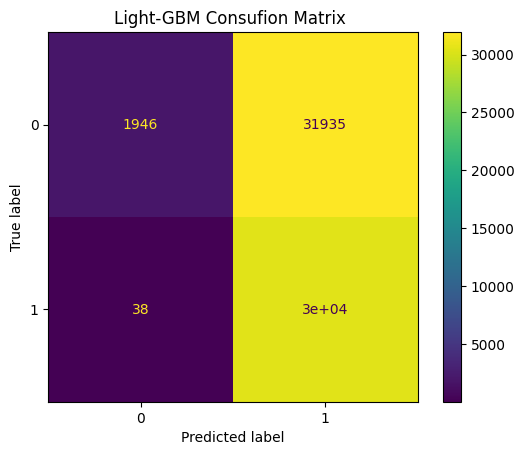

In [272]:
LGBM_pipe = Pipeline(steps= [ 
        ( 'preprocessor' , preprocessor ), 
        ( 'Light_GBM'  , LGBMClassifier(**LGBM_params))
    ])

LGBM_pipe.fit(X_train,y_train )
y_pred_raw = LGBM_pipe.predict_proba(X_test)[:, 1]

print(f'Accuracy Score : {roc_auc_score(y_test, y_pred_raw)}')

y_pred_raw= (y_pred_raw > threshold ).astype(int)
print(f'Precision Score : {precision_score(y_test, y_pred_raw )}')
print(f'Recall Score : {recall_score (y_test, y_pred_raw )}')

cm = confusion_matrix(y_test, y_pred_raw) 
disp = ConfusionMatrixDisplay(confusion_matrix = cm ) 

disp.plot()  
plt.title('Light-GBM Consufion Matrix ')
plt.show() 

In [258]:
y_prob = LGBM_pipe.predict_proba(X_test)[:, 1]

for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_temp = (y_prob > t).astype(int)   # ✅ use new variable
    
    print(f"Threshold: {t}")
    print(f"Precision: {precision_score(y_test, y_temp)}")
    print(f"Recall: {recall_score(y_test, y_temp)}")
    print("-"*30)



Threshold: 0.3
Precision: 0.48812347736889344
Recall: 0.9987538123503755
------------------------------
Threshold: 0.4
Precision: 0.4881391248597532
Recall: 0.9987538123503755
------------------------------
Threshold: 0.5
Precision: 0.4881391248597532
Recall: 0.9987538123503755
------------------------------
Threshold: 0.6
Precision: 0.4881547733538501
Recall: 0.9987538123503755
------------------------------
Threshold: 0.7
Precision: 0.48817824797627635
Recall: 0.9987538123503755
------------------------------


d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


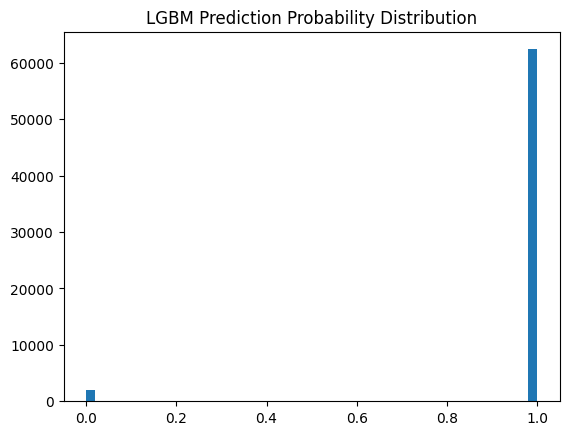

In [266]:

plt.hist(y_prob, bins=50)
plt.title("LGBM Prediction Probability Distribution")
plt.show()

### final Decision :- Using LightGBM Model fot the project 
#### With  :- 
1. threshold 0.5  
2. all best parameters 
3. fast traininig 
4. good for large dataset 

In [275]:
import joblib 
import os 

os.makedirs('../Models' , exist_ok=True )
joblib.dump(LGBM_pipe , '../Models/LGBM_pipe.pkl' )

['../Models/LGBM_pipe.pkl']